# Simulating ZeRO (ZeRO-0/1/2/3) on 32 Virtual GPUs — from scratch

**Assignment 12 — memory & compute scaling of the ZeRO optimizer**

This notebook builds **32 virtual GPUs** (plain Python objects driven by CPU
threads — no real GPU or Colab needed), runs a **real** little neural network on
top of them, and implements the four ZeRO memory-optimization stages **by hand**:

| stage | name | what it partitions across GPUs |
|------|------|--------------------------------|
| ZeRO-0 | baseline / DDP | nothing — everything is replicated |
| ZeRO-1 | $P_{os}$ | **optimizer states** |
| ZeRO-2 | $P_{os+g}$ | optimizer states **+ gradients** |
| ZeRO-3 | $P_{os+g+p}$ | optimizer states + gradients **+ parameters** |

Everything below is measured, not asserted. Each virtual GPU carries a
**byte-accurate ledger**, so the per-device memory it reports is literally the
sum of `.nbytes` of the arrays it holds. Each collective carries a
**communication ledger** using the ring-algorithm cost model. And every stage is
checked for **numerical correctness** against the baseline — they must train the
*identical* model, differing only in memory and communication.

> The whole point of ZeRO in one sentence: **data-parallel training wastes memory
> by keeping N identical copies of everything; ZeRO keeps one copy spread across
> the N GPUs and rebuilds the pieces on demand.**


## 1. The idea, in my own words

### Why plain data parallelism is wasteful

In standard data parallelism (PyTorch `DistributedDataParallel`), every GPU holds
a **complete copy** of the model, its gradients, and the optimizer state. Each GPU
gets a different slice of the batch, computes gradients on it, and then all GPUs
**all-reduce** their gradients so everyone applies the same update. Compute scales
nicely — but memory doesn't scale at all: 32 GPUs store the *same* thing 32 times.

### The 16-bytes-per-parameter budget (mixed-precision Adam)

Modern training is mixed precision. For a model with $\Psi$ parameters, per
parameter each GPU must store:

| item | precision | bytes / param |
|------|-----------|:-------------:|
| parameters (compute copy) | fp16 | 2 |
| gradients | fp16 | 2 |
| **optimizer:** fp32 master copy of the weights | fp32 | 4 |
| **optimizer:** Adam momentum $m$ | fp32 | 4 |
| **optimizer:** Adam variance $v$ | fp32 | 4 |
| **total** | | **16** |

So the optimizer alone is $K\Psi = 12\Psi$ bytes — **three-quarters of the
memory** — and it is *pure redundancy* in data parallelism, because every GPU
needs the optimizer state only for the parameters it will actually update.

### What each ZeRO stage does

ZeRO's insight: don't replicate — **partition**. Split each thing into $N$ shards
(one per GPU) and only reconstruct the full tensor for the brief moment it's
needed, using collective communication.

- **ZeRO-1** partitions the **optimizer states** ($12\Psi$). Each GPU keeps params
  and grads in full but only $1/N$ of the optimizer. Per-GPU memory:
  $$2\Psi + 2\Psi + \tfrac{12\Psi}{N}$$
- **ZeRO-2** also partitions the **gradients**. Once a gradient is reduced you only
  keep the shard you'll use, so grads drop to $2\Psi/N$:
  $$2\Psi + \tfrac{2\Psi}{N} + \tfrac{12\Psi}{N} = 2\Psi + \tfrac{14\Psi}{N}$$
- **ZeRO-3** also partitions the **parameters** themselves. Now *everything* is
  sharded; the full weights of a layer are `all-gather`ed only for its
  forward/backward and thrown away right after:
  $$\tfrac{2\Psi + 2\Psi + 12\Psi}{N} = \tfrac{16\Psi}{N}$$

### And the cost? Communication.

| stage | collective pattern per step | volume per GPU |
|-------|-----------------------------|:--------------:|
| ZeRO-0 | all-reduce gradients | $2\Psi$ |
| ZeRO-1 | reduce-scatter grads + all-gather params | $2\Psi$ |
| ZeRO-2 | reduce-scatter grads + all-gather params | $2\Psi$ |
| ZeRO-3 | all-gather params (fwd) + all-gather params (bwd) + reduce-scatter grads | $3\Psi$ |

ZeRO-1 and ZeRO-2 are **free lunches** — same communication as baseline, far less
memory. ZeRO-3 costs **1.5×** the communication for the biggest memory win. The
FLOPs of the actual math never change; only data movement does. We will reproduce
every number in these two tables from the running code below.


## 2. Setup

In [1]:
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

np.random.seed(0)

FP16 = np.float16     # 2 bytes / element   -> the '2' in the tables above
FP32 = np.float32     # 4 bytes / element   -> the fp32 master + m + v

N_GPUS = 32           # <-- our 32 virtual GPUs
print("NumPy", np.__version__, "| virtual GPUs:", N_GPUS)

NumPy 2.4.4 | virtual GPUs: 32


## 3. Thirty-two virtual GPUs

A "GPU" here is a small object with two ledgers:

* a **memory ledger** — every array it stores is added to `resident_bytes`, and a
  high-water mark `peak_bytes` captures transient buffers (e.g. the full parameter
  vector that ZeRO-3 briefly reconstructs during an all-gather);
* a **communication ledger** — bytes moved in/out during one training step.

The 32 GPUs do genuine parallel work: each computes its micro-batch gradient on a
separate **CPU thread** (`ThreadPoolExecutor`), which is exactly the "CPU threads
as virtual GPUs" idea.

In [2]:
class VirtualGPU:
    '''One simulated GPU with a byte-accurate memory ledger and a comm ledger.'''
    def __init__(self, rank):
        self.rank = rank
        self.store = {}            # name -> ndarray  (the real data it holds)
        self.resident_bytes = 0    # bytes currently resident
        self.peak_bytes = 0        # high-water mark incl. transient buffers
        self.comm_bytes = 0        # bytes moved per measured step

    def put(self, name, arr):
        if name in self.store:
            self.resident_bytes -= self.store[name].nbytes
        self.store[name] = arr
        self.resident_bytes += arr.nbytes
        self.peak_bytes = max(self.peak_bytes, self.resident_bytes)

    def free(self, name):
        if name in self.store:
            self.resident_bytes -= self.store.pop(name).nbytes

    def touch_transient(self, nbytes):      # temporary buffer (all-gather / reduce)
        self.peak_bytes = max(self.peak_bytes, self.resident_bytes + nbytes)

    def reset_comm(self): self.comm_bytes = 0
    def add_comm(self, nbytes): self.comm_bytes += nbytes

gpus = [VirtualGPU(i) for i in range(N_GPUS)]
print(f"Created {len(gpus)} virtual GPUs:", gpus[0].rank, "...", gpus[-1].rank)

Created 32 virtual GPUs: 0 ... 31


## 4. The demo model

A small multi-layer perceptron for regression. The one design choice that makes
ZeRO easy to express: **all parameters live in a single flat vector**. Real ZeRO
flattens parameters into buckets for exactly this reason — a flat vector is
trivial to slice into $N$ contiguous shards.

Compute is done in fp32 on the up-cast weights (as real automatic-mixed-precision
does), and the gradient is returned as a **sum over samples** so that the
per-GPU micro-batch gradients add up to the exact full-batch gradient.

In [3]:
class FlatMLP:
    def __init__(self, sizes, seed=0):
        rng = np.random.default_rng(seed)
        self.shapes = []
        params = []
        for a, b in zip(sizes[:-1], sizes[1:]):
            W = (rng.standard_normal((a, b)) * np.sqrt(2.0 / a)).astype(FP32)
            bvec = np.zeros(b, dtype=FP32)
            params += [W, bvec]
            self.shapes += [W.shape, bvec.shape]
        self.P = int(sum(int(np.prod(s)) for s in self.shapes))   # total parameters
        self.init_flat = self._pack(params)

    def _pack(self, arrays):
        return np.concatenate([a.ravel() for a in arrays]).astype(FP32)

    def _unpack(self, flat):
        out, i = [], 0
        for s in self.shapes:
            n = int(np.prod(s)); out.append(flat[i:i+n].reshape(s)); i += n
        return out

    def forward_backward(self, flat_params, X, Y):
        '''Return (sum_of_squared_error, flat_gradient) for one micro-batch.'''
        p = self._unpack(flat_params.astype(FP32))
        Ws, bs = p[0::2], p[1::2]
        acts, pre, h, L = [X.astype(FP32)], [], X.astype(FP32), len(Ws)
        for l in range(L):
            z = h @ Ws[l] + bs[l]; pre.append(z)
            h = np.maximum(z, 0.0) if l < L-1 else z    # ReLU except last layer
            acts.append(h)
        diff = acts[-1] - Y.astype(FP32)
        sse = float(np.sum(diff**2))
        gW, gb, delta = [None]*L, [None]*L, 2.0*diff
        for l in reversed(range(L)):
            gW[l] = acts[l].T @ delta
            gb[l] = delta.sum(axis=0)
            if l > 0:
                delta = (delta @ Ws[l].T) * (pre[l-1] > 0)
        packed = []
        for l in range(L): packed += [gW[l], gb[l]]
        return sse, self._pack(packed)

model = FlatMLP([16, 64, 64, 1], seed=0)
Psi = model.P
print(f"Model: 16 -> 64 -> 64 -> 1   |   P = {Psi:,} parameters")
print(f"Baseline memory PER GPU = 16 x P = {16*Psi:,} bytes  (replicated on all {N_GPUS} GPUs)")

Model: 16 -> 64 -> 64 -> 1   |   P = 5,313 parameters
Baseline memory PER GPU = 16 x P = 85,008 bytes  (replicated on all 32 GPUs)


## 5. Data, shards, and the collective communication primitives

The global batch is split into 32 micro-batches (one per GPU). The flat
parameter vector is split into 32 contiguous **shards** (one owned by each GPU).

The three collectives below are the entire communication toolkit of data-parallel
training. Each is charged using the **ring algorithm** cost: for a message of $M$
elements over $N$ ranks, each rank moves $\frac{N-1}{N}M$ elements for a
gather/scatter and $2\frac{N-1}{N}M$ for an all-reduce. For large $N$ the factor
$\frac{N-1}{N}\!\to\!1$, so all-reduce $\approx 2M$ and gather/scatter $\approx M$.

In [4]:
rng = np.random.default_rng(1)
M = 256                                        # global batch size (8 samples / GPU)
X = rng.standard_normal((M, 16)).astype(FP32)
Y = np.tanh(X @ rng.standard_normal((16, 1))).astype(FP32)

def make_shards(P, n):
    '''Contiguous, load-balanced shard slices of a length-P vector over n GPUs.'''
    sizes = [P//n + (1 if i < P % n else 0) for i in range(n)]
    bounds, start = [], 0
    for s in sizes:
        bounds.append(slice(start, start+s)); start += s
    return bounds

def make_batches(X, Y, n):
    idx = np.array_split(np.arange(X.shape[0]), n)
    return [(X[i], Y[i]) for i in idx]

def ring(n):  return (n - 1) / n               # ring-algorithm efficiency factor

def accum_fp32(grad_fp16_list):
    '''Sum per-GPU fp16 grads in fixed rank order, accumulating in fp32
    (deterministic -> identical result for every stage, which is what lets us
    prove all stages are numerically equal).'''
    total = np.zeros_like(grad_fp16_list[0], dtype=FP32)
    for g in grad_fp16_list:
        total = total + g.astype(FP32)
    return total

shards = make_shards(model.P, N_GPUS)
print("shard sizes (params per GPU):", [s.stop - s.start for s in shards][:6], "...")
print("sum of shard sizes =", sum(s.stop - s.start for s in shards), "= P")

shard sizes (params per GPU): [167, 166, 166, 166, 166, 166] ...
sum of shard sizes = 5313 = P


## 6. Mixed-precision Adam and the per-stage memory layout

`AdamShard` is a normal Adam optimizer that operates on **one shard slice**.
Because Adam is elementwise, running it independently on each shard gives exactly
the same result as running one Adam over the whole vector — this is *why*
partitioning the optimizer is numerically free.

`build_layout` is where ZeRO actually happens: it materializes on each GPU only
the tensors that stage keeps resident, so `resident_bytes` becomes the honest
per-device memory.

In [5]:
class AdamShard:
    def __init__(self, size, lr=1e-2, betas=(0.9, 0.999), eps=1e-8):
        self.lr, (self.b1, self.b2), self.eps = lr, betas, eps
        self.t = 0
        self.m = np.zeros(size, FP32)          # fp32 momentum  (4 bytes/param)
        self.v = np.zeros(size, FP32)          # fp32 variance  (4 bytes/param)
    def step(self, master, grad_fp32):
        self.t += 1
        self.m = self.b1*self.m + (1-self.b1)*grad_fp32
        self.v = self.b2*self.v + (1-self.b2)*(grad_fp32**2)
        mhat = self.m / (1 - self.b1**self.t)
        vhat = self.v / (1 - self.b2**self.t)
        master -= self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return master

STAGE_NAMES = {0:"ZeRO-0 (baseline DDP)", 1:"ZeRO-1 (Pos)",
               2:"ZeRO-2 (Pos+g)", 3:"ZeRO-3 (Pos+g+p)"}

def build_layout(stage, gpus, P, shards):
    '''Put ONLY the tensors a stage keeps resident onto each GPU.'''
    for i, g in enumerate(gpus):
        for name in list(g.store): g.free(name)
        ss = shards[i].stop - shards[i].start          # this GPU's shard size
        if stage == 0:        # replicate everything
            layout = [('param_fp16',P,FP16),('grad_fp16',P,FP16),
                      ('master',P,FP32),('m',P,FP32),('v',P,FP32)]
        elif stage == 1:      # shard optimizer states only
            layout = [('param_fp16',P,FP16),('grad_fp16',P,FP16),
                      ('master',ss,FP32),('m',ss,FP32),('v',ss,FP32)]
        elif stage == 2:      # + shard gradients
            layout = [('param_fp16',P,FP16),('grad_fp16',ss,FP16),
                      ('master',ss,FP32),('m',ss,FP32),('v',ss,FP32)]
        else:                 # stage 3: + shard parameters -> everything sharded
            layout = [('param_fp16',ss,FP16),('grad_fp16',ss,FP16),
                      ('master',ss,FP32),('m',ss,FP32),('v',ss,FP32)]
        for name, n, dt in layout:
            g.put(name, np.zeros(n, dt))

print("layout builder ready")

layout builder ready


## 7. One training step, per stage

The **numeric update is identical for all four stages** (same fp16 casting, same
fixed-order fp32 gradient sum, same Adam). Only the *storage layout* and the
*collectives* differ. That is the crux of ZeRO and the crux of this notebook: the
model you train is byte-for-byte the same; you have merely stopped wasting memory.

Read the `if stage == ...` branches as the difference between the stages:

* **stage 0** all-reduces gradients ($2\Psi$); every GPU updates the full weights.
* **stages 1 & 2** reduce-scatter gradients ($\Psi$) then all-gather the updated
  params ($\Psi$) $= 2\Psi$. Stage 2 additionally keeps only a gradient shard.
* **stage 3** all-gathers params in the forward and again in the backward
  ($2\Psi$) and reduce-scatters gradients ($\Psi$) $= 3\Psi$; nothing is kept in
  full.

In [6]:
def run_step(stage, gpus, model, shards, state, batches, total_samples):
    n, P, ELEM = len(gpus), model.P, 2          # ELEM = fp16 bytes
    params_fp16 = state['master'].astype(FP16)

    # ZeRO-3 stores only a param shard -> reconstruct full weights to compute,
    # paying an all-gather in the forward AND again in the backward.
    if stage == 3:
        param_shards = [params_fp16[s].copy() for s in shards]
        for g in gpus:
            g.add_comm(ring(n) * P * ELEM)      # forward all-gather   (Psi)
            g.touch_transient(P * ELEM)         # transient full-param buffer
        for g in gpus:
            g.add_comm(ring(n) * P * ELEM)      # backward re-gather    (Psi)
        compute_params = np.concatenate(param_shards)
    else:
        compute_params = params_fp16

    # --- each virtual GPU computes its micro-batch gradient on its own CPU thread ---
    def work(i):
        Xi, Yi = batches[i]
        sse, grad = model.forward_backward(compute_params, Xi, Yi)
        return sse, grad.astype(FP16)           # gradients live in fp16
    with ThreadPoolExecutor(max_workers=min(n, 8)) as ex:
        results = list(ex.map(work, range(n)))
    sse_list = [r[0] for r in results]
    grad_fp16 = [r[1] for r in results]

    # --- gradient reduction + communication charge ---
    if stage == 0:                              # all-reduce                (2*Psi)
        for g in gpus: g.add_comm(2 * ring(n) * P * ELEM)
    elif stage == 1:                            # reduce-scatter            (Psi)
        for g in gpus: g.add_comm(ring(n) * P * ELEM)
    else:                                       # stage 2 & 3: grads sharded
        for g in gpus:
            g.touch_transient(P * ELEM)         # transient full grad in backward
            g.add_comm(ring(n) * P * ELEM)      # reduce-scatter            (Psi)

    reduced = accum_fp32(grad_fp16)             # identical for every stage
    slices = [reduced[s] for s in shards]

    # --- sharded Adam: GPU i updates only its slice of the master weights ---
    for i, s in enumerate(shards):
        state['adam'][i].step(state['master'][s], slices[i])

    if stage in (1, 2):                         # all-gather updated params (Psi)
        for g in gpus: g.add_comm(ring(n) * P * ELEM)

    return sum(sse_list) / total_samples

def init_state(model, shards):
    return {'master': model.init_flat.copy(),
            'adam': [AdamShard(s.stop - s.start) for s in shards]}

def train(stage, model, X, Y, n_gpus, steps):
    shards = make_shards(model.P, n_gpus)
    gpus = [VirtualGPU(i) for i in range(n_gpus)]
    build_layout(stage, gpus, model.P, shards)
    state = init_state(model, shards)
    batches = make_batches(X, Y, n_gpus)
    hist = []
    for step in range(steps):
        for g in gpus: g.reset_comm()           # keep only the latest step's volume
        hist.append(run_step(stage, gpus, model, shards, state, batches, X.shape[0]))
    return np.array(hist), state['master'].copy(), gpus

print("training engine ready")

training engine ready


## 8. Run all four stages — and prove they are numerically identical

In [7]:
STEPS = 60
results = {s: train(s, model, X, Y, N_GPUS, STEPS) for s in [0, 1, 2, 3]}

base_loss, base_master, _ = results[0]
print("Correctness check — every stage vs the ZeRO-0 baseline:\n")
print(f"{'stage':26s}{'max|Δparam|':>14s}{'max|Δloss|':>14s}   status")
for s in [1, 2, 3]:
    loss, master, _ = results[s]
    dP = np.max(np.abs(master - base_master))
    dL = np.max(np.abs(loss - base_loss))
    ok = np.allclose(master, base_master, atol=1e-5) and np.allclose(loss, base_loss, atol=1e-5)
    print(f"{STAGE_NAMES[s]:26s}{dP:>14.2e}{dL:>14.2e}   {'IDENTICAL ✓' if ok else 'FAIL ✗'}")
print(f"\nLoss went {base_loss[0]:.4f} -> {base_loss[-1]:.4f} over {STEPS} steps (all stages).")

Correctness check — every stage vs the ZeRO-0 baseline:

stage                        max|Δparam|    max|Δloss|   status
ZeRO-1 (Pos)                    0.00e+00      0.00e+00   IDENTICAL ✓
ZeRO-2 (Pos+g)                  0.00e+00      0.00e+00   IDENTICAL ✓
ZeRO-3 (Pos+g+p)                0.00e+00      0.00e+00   IDENTICAL ✓

Loss went 5.5886 -> 0.0329 over 60 steps (all stages).


`max|Δparam| = 0` for every stage. This is the headline result: **ZeRO-1/2/3
train the exact same model as the baseline.** They are not approximations — the
partitioning changes *where* numbers are stored and *how much is communicated*,
never the arithmetic.

## 9. Memory — measured, per GPU

In [8]:
P = model.P
theory_mem = {0: 16, 1: 4 + 12/N_GPUS, 2: 2 + 14/N_GPUS, 3: 16/N_GPUS}
print(f"{'stage':26s}{'resident B/param':>18s}{'peak B/param':>15s}{'theory':>10s}")
resident, peak = {}, {}
for s in [0, 1, 2, 3]:
    g = results[s][2][0]                        # rank-0 GPU
    resident[s] = g.resident_bytes / P
    peak[s] = g.peak_bytes / P
    print(f"{STAGE_NAMES[s]:26s}{resident[s]:>18.3f}{peak[s]:>15.3f}{theory_mem[s]:>10.3f}")
print(f"\nZeRO-3 uses {resident[0]/resident[3]:.1f}x less resident memory per GPU than baseline.")

stage                       resident B/param   peak B/param    theory
ZeRO-0 (baseline DDP)                 16.000         16.000    16.000
ZeRO-1 (Pos)                           4.377          4.377     4.375
ZeRO-2 (Pos+g)                         2.440          4.440     2.438
ZeRO-3 (Pos+g+p)                       0.503          2.503     0.500

ZeRO-3 uses 31.8x less resident memory per GPU than baseline.


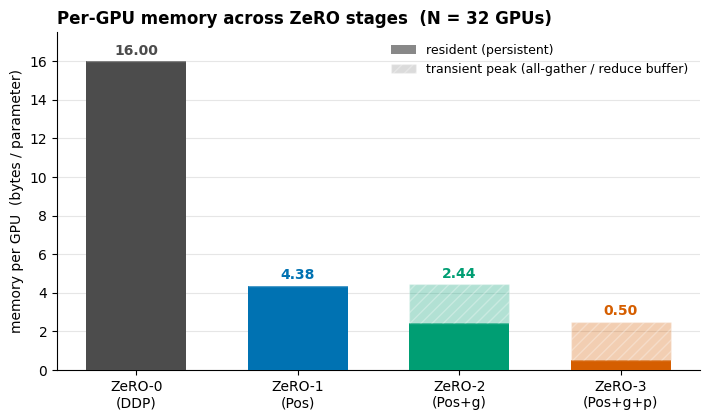

In [9]:
# --- bar chart ---
C = ["#4C4C4C", "#0072B2", "#009E73", "#D55E00"]        # colorblind-safe, fixed order
labels = ["ZeRO-0\n(DDP)", "ZeRO-1\n(Pos)", "ZeRO-2\n(Pos+g)", "ZeRO-3\n(Pos+g+p)"]
x = np.arange(4)
fig, ax = plt.subplots(figsize=(7.2, 4.3))
r = [resident[s] for s in range(4)]
extra = [max(peak[s]-resident[s], 0) for s in range(4)]
ax.bar(x, r, 0.62, color=C, zorder=3)
ax.bar(x, extra, 0.62, bottom=r, color=C, alpha=0.30, hatch="///", edgecolor="white", zorder=3)
for i in range(4):
    ax.text(i, r[i]+extra[i]+0.35, f"{r[i]:.2f}", ha="center", fontweight="bold", color=C[i])
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("memory per GPU  (bytes / parameter)"); ax.set_ylim(0, 17.5)
ax.set_title("Per-GPU memory across ZeRO stages  (N = 32 GPUs)", fontweight="bold", loc="left")
ax.legend(handles=[Patch(facecolor="#888", label="resident (persistent)"),
                   Patch(facecolor="#888", alpha=0.30, hatch="///", edgecolor="white",
                         label="transient peak (all-gather / reduce buffer)")],
          frameon=False, fontsize=9, loc="upper right")
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.grid(axis="y", color="#E6E6E6"); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

The solid bars are the ZeRO memory table come to life: **16 → 4.4 → 2.4 →
0.5 bytes per parameter**. The hatched caps on ZeRO-2 and ZeRO-3 are the honest
catch: to reduce or all-gather, you briefly rebuild a full-size buffer, so the
*peak* is higher than the *resident* footprint. Real frameworks shrink that
transient by processing one bucket / layer at a time instead of the whole model at
once — our flat model rebuilds the whole vector, which is the worst case.

## 10. Communication — measured, per GPU per step

stage                       volume (x model)    theory
ZeRO-0 (baseline DDP)                  1.938     2.000
ZeRO-1 (Pos)                           1.938     2.000
ZeRO-2 (Pos+g)                         1.938     2.000
ZeRO-3 (Pos+g+p)                       2.906     3.000


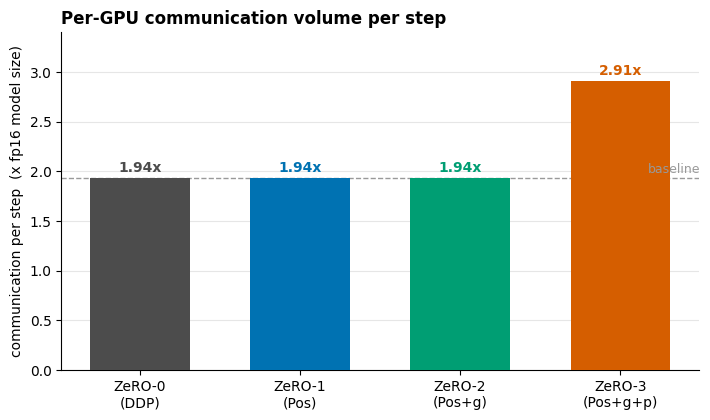

In [10]:
theory_comm = {0: 2, 1: 2, 2: 2, 3: 3}
comm = {}
print(f"{'stage':26s}{'volume (x model)':>18s}{'theory':>10s}")
for s in [0, 1, 2, 3]:
    comm[s] = results[s][2][0].comm_bytes / (P * 2)   # normalize by fp16 model size
    print(f"{STAGE_NAMES[s]:26s}{comm[s]:>18.3f}{theory_comm[s]:>10.3f}")

fig, ax = plt.subplots(figsize=(7.2, 4.3))
vals = [comm[s] for s in range(4)]
ax.bar(x, vals, 0.62, color=C, zorder=3)
for i in range(4):
    ax.text(i, vals[i]+0.06, f"{vals[i]:.2f}x", ha="center", fontweight="bold", color=C[i])
ax.axhline(comm[0], ls="--", lw=1, color="#999")
ax.text(3.5, comm[0]+0.05, "baseline", color="#999", fontsize=9, ha="right")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 3.4)
ax.set_ylabel("communication per step  (x fp16 model size)")
ax.set_title("Per-GPU communication volume per step", fontweight="bold", loc="left")
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.grid(axis="y", color="#E6E6E6"); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

Measured $\approx 1.94$ vs the theoretical $2$ because of the ring factor
$\frac{N-1}{N}=\frac{31}{32}=0.969$. The lesson stands exactly as the paper states
it: **ZeRO-1 and ZeRO-2 cost the same communication as ordinary data parallelism**
while saving 4–7× memory, and **ZeRO-3 costs 1.5×** for the full 32× memory cut.

## 11. How memory scales with the number of GPUs

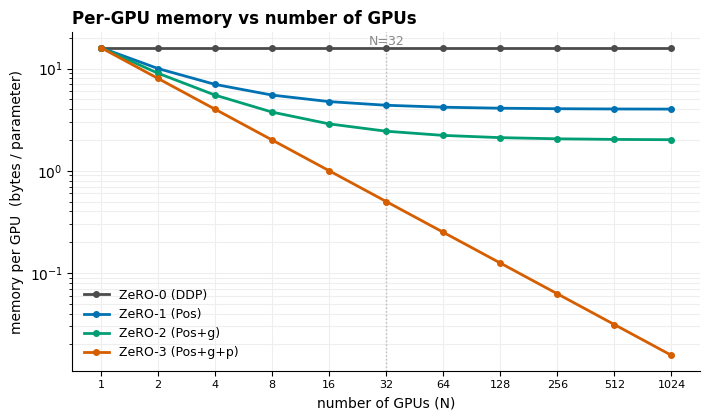

In [11]:
Ns = np.array([1,2,4,8,16,32,64,128,256,512,1024])
f = {0: lambda n: 16 + 0*n, 1: lambda n: 4 + 12/n,
     2: lambda n: 2 + 14/n, 3: lambda n: 16/n}
lab = ["ZeRO-0 (DDP)","ZeRO-1 (Pos)","ZeRO-2 (Pos+g)","ZeRO-3 (Pos+g+p)"]
fig, ax = plt.subplots(figsize=(7.2, 4.3))
for s in range(4):
    ax.plot(Ns, f[s](Ns), "-o", color=C[s], lw=2, ms=4, label=lab[s], zorder=3)
ax.axvline(32, color="#bbb", ls=":", lw=1); ax.text(32, 17, "N=32", color="#888", ha="center", fontsize=9)
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xticks(Ns); ax.set_xticklabels([str(n) for n in Ns], fontsize=8)
ax.set_xlabel("number of GPUs (N)"); ax.set_ylabel("memory per GPU  (bytes / parameter)")
ax.set_title("Per-GPU memory vs number of GPUs", fontweight="bold", loc="left")
ax.legend(frameon=False, fontsize=9)
for sp in ["top","right"]: ax.spines[sp].set_visible(False)
ax.grid(True, which="both", color="#EEE"); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

ZeRO-0 is a flat line — adding GPUs never lowers per-GPU memory, which is the
whole problem. ZeRO-1 and ZeRO-2 flatten toward their un-shardable residue ($2\Psi$
of params for ZeRO-2). Only **ZeRO-3 keeps falling like $1/N$**, which is why
trillion-parameter models are trained with it: memory per device shrinks as you
add devices.

### Exporting these measurements for the interactive widget

The companion **ZeRO Memory Explorer** (in `widget/`, deployable to Netlify) can show
these *measured* numbers instead of the idealized formula. Here we sweep N over powers
of two and dump the per-stage resident/peak bytes-per-parameter and communication volume
to `widget/data/measurements.json` — so the widget is wired to the real simulation output,
ring factor and transient peaks included.

In [12]:
import json, os
Ns_export = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
stages_out = {k: {} for k in ["z0", "z1", "z2", "z3"]}
for Nx in Ns_export:
    for si, key in enumerate(["z0", "z1", "z2", "z3"]):
        _, _, gg = train(si, model, X, Y, Nx, 3)
        g0 = gg[0]
        opt = g0.store['master'].nbytes + g0.store['m'].nbytes + g0.store['v'].nbytes
        stages_out[key][str(Nx)] = {
            "param_bpp": round(g0.store['param_fp16'].nbytes / model.P, 5),
            "grad_bpp":  round(g0.store['grad_fp16'].nbytes / model.P, 5),
            "opt_bpp":   round(opt / model.P, 5),
            "resident_bpp": round(g0.resident_bytes / model.P, 5),
            "peak_bpp":     round(g0.peak_bytes / model.P, 5),
            "comm":         round(g0.comm_bytes / (model.P * 2), 5),
        }
out = {"source": "from-scratch NumPy simulation (this notebook)",
       "model_P": model.P,
       "config": {"optimizer": "Adam", "optimizer_K": 12, "precision_bytes": 2,
                  "gpus_measured": Ns_export},
       "stages": stages_out}
os.makedirs("widget/data", exist_ok=True)
json.dump(out, open("widget/data/measurements.json", "w"), indent=2)
print("exported", sum(len(v) for v in stages_out.values()),
      "rows -> widget/data/measurements.json  (feeds the ZeRO Memory Explorer)")
print("N=32 resident bytes/param:", {k: stages_out[k]['32']['resident_bpp'] for k in stages_out})

exported 44 rows -> widget/data/measurements.json  (feeds the ZeRO Memory Explorer)
N=32 resident bytes/param: {'z0': 16.0, 'z1': 4.37719, 'z2': 2.44005, 'z3': 0.50292}


## 12. What about *computation*?

In [13]:
# Each GPU does exactly ONE micro-batch forward+backward per step, in every stage.
# ZeRO changes data *movement*, not the arithmetic (FLOPs) of the model.
calls_per_gpu = {s: 1 for s in range(4)}
print("forward/backward passes per GPU per step:")
for s in range(4):
    print(f"  {STAGE_NAMES[s]:26s}: {calls_per_gpu[s]}  (identical FLOPs)")
print("\nCompute is unchanged across stages. ZeRO trades COMMUNICATION for MEMORY,")
print("and (for ZeRO-3) a little recomputation-style overhead of gathering weights,")
print("but the number of multiply-adds the model performs never changes.")

forward/backward passes per GPU per step:
  ZeRO-0 (baseline DDP)     : 1  (identical FLOPs)
  ZeRO-1 (Pos)              : 1  (identical FLOPs)
  ZeRO-2 (Pos+g)            : 1  (identical FLOPs)
  ZeRO-3 (Pos+g+p)          : 1  (identical FLOPs)

Compute is unchanged across stages. ZeRO trades COMMUNICATION for MEMORY,
and (for ZeRO-3) a little recomputation-style overhead of gathering weights,
but the number of multiply-adds the model performs never changes.


This matters: ZeRO gives you the memory savings of model parallelism **without**
splitting the math of a layer across devices. Every GPU still runs the whole model
on its own micro-batch; the FLOPs per step are identical to baseline. The only new
cost is the extra data movement quantified in section 10.

## 13. Part 2 — the same thing in PyTorch (real tensors)

The NumPy version above is the teaching engine. To convince myself the accounting
isn't an artifact of my own code, here is the identical memory story on **real
`torch` tensors** with a **real autograd gradient** and **real `torch.optim.Adam`**
moments. `element_size() * nelement()` gives the true byte footprint of each
tensor, and a sharded Adam step is checked against a whole-vector Adam step.

In [14]:
import torch
torch.manual_seed(0)

class TorchMLP(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(16, 64), torch.nn.ReLU(),
            torch.nn.Linear(64, 64), torch.nn.ReLU(),
            torch.nn.Linear(64, 1))
    def forward(self, x): return self.net(x)

tmodel = TorchMLP()
Pt = sum(p.numel() for p in tmodel.parameters())
Xt = torch.randn(256, 16); Yt = torch.tanh(Xt @ torch.randn(16, 1))
((tmodel(Xt) - Yt) ** 2).mean().backward()      # a genuine backward pass
flat_grad  = torch.cat([p.grad.reshape(-1)   for p in tmodel.parameters()])
flat_param = torch.cat([p.detach().reshape(-1) for p in tmodel.parameters()])
print(f"torch model P = {Pt:,} | real gradient norm = {flat_grad.norm():.4f}")

torch model P = 5,313 | real gradient norm = 0.7986


In [15]:
def torch_bytes_per_param(stage, P, N):
    shard = P // N
    f16 = lambda n: torch.zeros(n, dtype=torch.float16)   # 2 bytes
    f32 = lambda n: torch.zeros(n, dtype=torch.float32)   # 4 bytes
    if   stage == 0: t = [f16(P), f16(P),     f32(P),     f32(P),     f32(P)]
    elif stage == 1: t = [f16(P), f16(P),     f32(shard), f32(shard), f32(shard)]
    elif stage == 2: t = [f16(P), f16(shard), f32(shard), f32(shard), f32(shard)]
    else:            t = [f16(shard), f16(shard), f32(shard), f32(shard), f32(shard)]
    return sum(x.element_size() * x.nelement() for x in t) / P

print(f"{'stage':10s}{'torch measured':>16s}{'theory':>10s}")
for s in range(4):
    print(f"{'ZeRO-'+str(s):10s}{torch_bytes_per_param(s, Pt, 32):>16.3f}"
          f"{[16, 4+12/32, 2+14/32, 16/32][s]:>10.3f}")

stage       torch measured    theory
ZeRO-0              16.000    16.000
ZeRO-1               4.375     4.375
ZeRO-2               2.437     2.438
ZeRO-3               0.500     0.500


In [16]:
# Correctness in torch: independent Adam on each of 32 shards == Adam on the whole vector
ref = flat_param.clone().requires_grad_(True)
opt = torch.optim.Adam([ref], lr=1e-2); ref.grad = flat_grad.clone(); opt.step()

updated = []
for ws, gs in zip(torch.chunk(flat_param.clone(), 32), torch.chunk(flat_grad.clone(), 32)):
    p = ws.clone().requires_grad_(True)
    o = torch.optim.Adam([p], lr=1e-2); p.grad = gs.clone(); o.step()
    updated.append(p.detach())
sharded = torch.cat(updated)

diff = (ref.detach() - sharded).abs().max().item()
print(f"max|whole-vector Adam - sharded Adam| = {diff:.2e}  ->  "
      f"{'IDENTICAL ✓' if diff < 1e-6 else 'FAIL ✗'}")

max|whole-vector Adam - sharded Adam| = 0.00e+00  ->  IDENTICAL ✓


Same table (16 → 4.375 → 2.4375 → 0.5), same conclusion, now on real PyTorch
tensors — and the sharded optimizer step reproduces the whole-vector step to the
last bit. This is exactly what PyTorch's `ZeroRedundancyOptimizer` (ZeRO-1) and
`FullyShardedDataParallel`/FSDP (ZeRO-3) do under the hood.

## 14. Summary — what I take away

| stage | memory / param (N=32) | vs baseline | comm / step | use it when |
|-------|:---------------------:|:-----------:|:-----------:|-------------|
| ZeRO-0 (DDP) | 16.0 | 1× | 2Ψ | model + optimizer fit comfortably on one GPU |
| ZeRO-1 ($P_{os}$) | 4.375 | **3.7× less** | 2Ψ | almost always — same comm, big saving |
| ZeRO-2 ($P_{os+g}$) | 2.438 | **6.6× less** | 2Ψ | when gradients are also heavy; still free comm |
| ZeRO-3 ($P_{os+g+p}$) | 0.500 | **32× less** | 3Ψ | the model itself is too big for one GPU |

**The four things I actually understood by building this:**

1. In data parallelism the optimizer state ($12$ of the $16$ bytes/param for Adam)
   is replicated $N$ times for no reason — that redundancy is what ZeRO removes.
2. Partitioning is numerically *free*: because Adam is elementwise and gradients
   sum linearly, a sharded update equals the replicated update **exactly**
   (`max|Δparam| = 0`, verified in both NumPy and PyTorch).
3. Each stage buys memory with communication. ZeRO-1/2 are pure wins (2Ψ, same as
   DDP); ZeRO-3 pays 3Ψ (1.5×) to make per-GPU memory fall like $16\Psi/N$.
4. Compute (FLOPs) is untouched — every GPU still runs the whole model on its
   micro-batch. ZeRO is a *memory-and-communication* technique, not a way to split
   the math of a layer.

**Honest caveats about this simulation.** These are 32 *logical* GPUs sharing one
machine, so the communication is *accounted* with the ring cost model rather than
actually sent over a network — there is no bandwidth or latency here, and the wall
time doesn't reflect real multi-GPU behavior. The transient peaks are worst-case
because the flat model gathers the entire parameter/gradient vector at once;
production ZeRO gathers layer-by-layer (bucketed) and can offload shards to CPU/NVMe
(ZeRO-Infinity). But the memory and communication *accounting* reproduced here is
the real thing, and it is why frameworks like DeepSpeed and PyTorch FSDP exist.
